In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

print("✅ Mixed Precision Aktif! GPU akan berlari 2x lebih kencang.")

print("TensorFlow Version:", tf.__version__)
# Cek ketersediaan GPU
print("GPU Available:", tf.config.list_physical_devices('GPU'))

2026-03-26 13:49:58.622717: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774532998.994584      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774532999.130791      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774533000.177961      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774533000.178023      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774533000.178029      55 computation_placer.cc:177] computation placer alr

✅ Mixed Precision Aktif! GPU akan berlari 2x lebih kencang.
TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# --- KONFIGURASI ---
TRAIN_DIR = '/kaggle/input/datasets/ananthu017/emotion-detection-fer/train' # Ganti dengan path folder train kamu
VALID_DIR = '/kaggle/input/datasets/ananthu017/emotion-detection-fer/test' # Ganti dengan path folder test/validasi
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CLASSES = ['happy', 'sad', 'angry', 'surprised'] # Fokus ke 4 label game

# 1. Load Data Super Cepat (tanpa rescale 1./255!)
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=CLASSES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    labels='inferred',
    label_mode='categorical',
    class_names=CLASSES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# 2. Optimasi Pipeline (Prefetching agar GPU tidak nunggu)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("✅ Data Pipeline Modern Siap!")

Found 19211 files belonging to 4 classes.


I0000 00:00:1774533046.046391      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 4810 files belonging to 4 classes.
✅ Data Pipeline Modern Siap!


In [3]:
# Ambil label murni untuk menghitung class weight
# tf.data agak unik cara ambil labelnya
train_labels = []
for images, labels in train_ds.unbatch():
    train_labels.append(np.argmax(labels.numpy()))

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_dict = dict(enumerate(class_weights))

print("⚖️ Bobot Kelas:")
for i, weight in class_weights_dict.items():
    print(f" - {CLASSES[i]}: {weight:.2f}")

⚖️ Bobot Kelas:
 - happy: 0.67
 - sad: 0.99
 - angry: 1.20
 - surprised: 1.51


In [4]:
# 1. Buat Layer Augmentasi (Berjalan langsung di dalam GPU)
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
  layers.RandomTranslation(0.1, 0.1),
], name="gpu_augmentation")

# 2. Load Otak EfficientNet (Tanpa kepalanya)
base_model = applications.EfficientNetB0(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Freeze dulu!

# 3. Rakit Arsitektur Utuh
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs) # Gambar diacak
x = base_model(x, training=False) # Masuk ke EfficientNet (sudah auto-normalize)

# Transisi yang halus (Classification Head baru)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x) # Cegah overfitting
x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(CLASSES), activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

# Compile dengan Adam (learning rate kecil untuk transfer learning)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gpu_augmentation (Sequential)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,219,687 (16.10 MB)

 Trainable params: 167,300 (653.52 KB)

 Non-trainable params: 4,052,387 (15.46 MB)

In [5]:
# Callback modern: Berhenti kalau nyangkut, turunkan LR kalau melambat
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.3, patience=2)
]

print("🚀 Memulai Pemanasan (Phase 1)...")
history_1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15, 
    callbacks=callbacks,
    class_weight=class_weights_dict # Paksa agar adil!
)

🚀 Memulai Pemanasan (Phase 1)...
Epoch 1/15


E0000 00:00:1774533096.445782      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1774533098.963341     124 cuda_dnn.cc:529] Loaded cuDNN version 91002


601/601 ━━━━━━━━━━━━━━━━━━━━ 91s 108ms/step - accuracy: 0.4544 - loss: 1.4172 - val_accuracy: 0.6405 - val_loss: 0.8804 - learning_rate: 0.0010
Epoch 2/15
601/601 ━━━━━━━━━━━━━━━━━━━━ 40s 67ms/step - accuracy: 0.5515 - loss: 1.0341 - val_accuracy: 0.6532 - val_loss: 0.8451 - learning_rate: 0.0010
Epoch 3/15
601/601 ━━━━━━━━━━━━━━━━━━━━ 40s 67ms/step - accuracy: 0.5824 - loss: 0.9758 - val_accuracy: 0.6478 - val_loss: 0.8495 - learning_rate: 0.0010
Epoch 4/15
601/601 ━━━━━━━━━━━━━━━━━━━━ 40s 67ms/step - accuracy: 0.5914 - loss: 0.9612 - val_accuracy: 0.6615 - val_loss: 0.8248 - learning_rate: 0.0010
Epoch 5/15
601/601 ━━━━━━━━━━━━━━━━━━━━ 40s 67ms/step - accuracy: 0.5944 - loss: 0.9589 - val_accuracy: 0.6626 - val_loss: 0.8152 - learning_rate: 0.0010
Epoch 6/15
601/601 ━━━━━━━━━━━━━━━━━━━━ 40s 67ms/step - accuracy: 0.5926 - loss: 0.9445 - val_accuracy: 0.6701 - val_loss: 0.8083 - learning_rate: 0.0010
Epoch 7/15
601/601 ━━━━━━━━━━━━━━━━━━━━ 40s 66ms/step - accuracy: 0.6041 - loss: 0.931

In [6]:
print("🔓 Membuka SEMUA Gembok EfficientNet (Full Fine-Tuning Phase 2)...")

# 1. Unfreeze SELURUH layer EfficientNetB0
base_model.trainable = True

# Opsional tapi penting: Biarkan layer BatchNormalization tetap beku 
# agar tidak merusak statistik mean/variance dari ImageNet
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

# 2. Compile ulang dengan Learning Rate yang SUPER KECIL (5e-5)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5), # Turun dari 1e-4 ke 5e-5
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# 3. Callback lebih agresif untuk mencari akurasi tertinggi
callbacks_phase2 = [
    # Save bobot model TERBAIK saja, bukan bobot di akhir epoch
    tf.keras.callbacks.ModelCheckpoint(
        "best_efficientnet_game.keras", 
        monitor="val_accuracy", 
        save_best_only=True, 
        mode="max", 
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=3, min_lr=1e-6)
]

print("🔥 Memulai Full Fine-Tuning...")
history_2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,  # Karena sudah pakai GPU, hajar saja 25 Epoch
    callbacks=callbacks_phase2,
    class_weight=class_weights_dict
)

print("🎉 Selesai! Cek file 'best_efficientnet_game.keras' untuk model dengan akurasi tertinggi.")

🔓 Membuka SEMUA Gembok EfficientNet (Full Fine-Tuning Phase 2)...
🔥 Memulai Full Fine-Tuning...
Epoch 1/25


E0000 00:00:1774533759.861340      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


601/601 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.6627 - loss: 0.9733
Epoch 1: val_accuracy improved from -inf to 0.76736, saving model to best_efficientnet_game.keras
601/601 ━━━━━━━━━━━━━━━━━━━━ 198s 242ms/step - accuracy: 0.6628 - loss: 0.9732 - val_accuracy: 0.7674 - val_loss: 0.7966 - learning_rate: 5.0000e-05
Epoch 2/25
601/601 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.7324 - loss: 0.8635
Epoch 2: val_accuracy improved from 0.76736 to 0.76902, saving model to best_efficientnet_game.keras
601/601 ━━━━━━━━━━━━━━━━━━━━ 114s 190ms/step - accuracy: 0.7324 - loss: 0.8634 - val_accuracy: 0.7690 - val_loss: 0.7904 - learning_rate: 5.0000e-05
Epoch 3/25
601/601 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.7622 - loss: 0.8029
Epoch 3: val_accuracy improved from 0.76902 to 0.79834, saving model to best_efficientnet_game.keras
601/601 ━━━━━━━━━━━━━━━━━━━━ 114s 190ms/step - accuracy: 0.7622 - loss: 0.8029 - val_accuracy: 0.7983 - val_loss: 0.7383 - learning_rate: 5.0000e-05


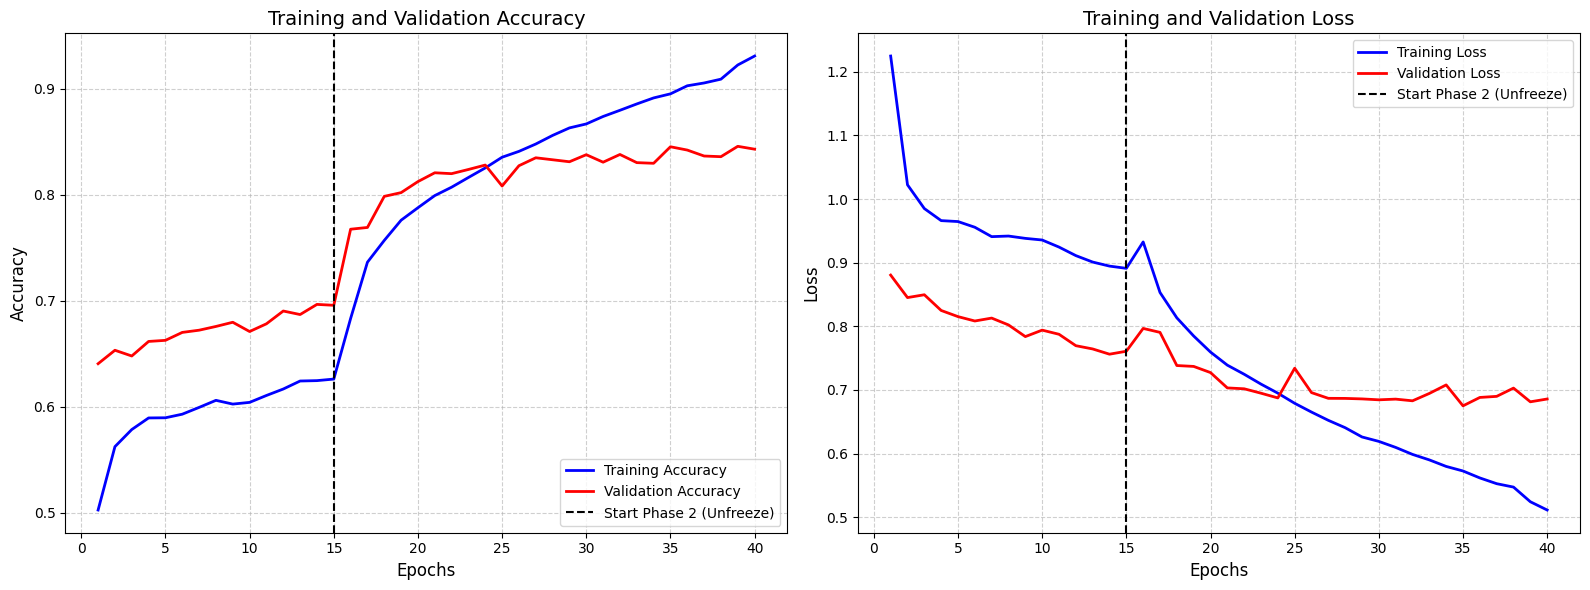

⏳ Sedang memprediksi data validasi untuk evaluasi akhir...
151/151 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step

📊 LAPORAN METRIK EVALUASI (CLASSIFICATION REPORT)
              precision    recall  f1-score   support

       happy     0.9184    0.9329    0.9256      1774
         sad     0.7863    0.7819    0.7841      1247
       angry     0.7598    0.7296    0.7444       958
   surprised     0.8703    0.8881    0.8791       831

    accuracy                         0.8455      4810
   macro avg     0.8337    0.8331    0.8333      4810
weighted avg     0.8443    0.8455    0.8448      4810



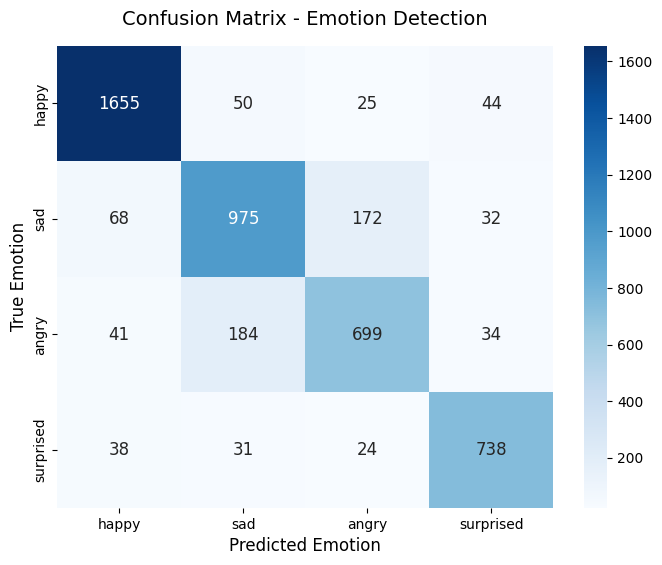

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# ==========================================
# 1. VISUALISASI GRAFIK TRAINING vs VALIDATION
# ==========================================
# Menggabungkan history Phase 1 dan Phase 2
acc = history_1.history['accuracy'] + history_2.history['accuracy']
val_acc = history_1.history['val_accuracy'] + history_2.history['val_accuracy']
loss = history_1.history['loss'] + history_2.history['loss']
val_loss = history_1.history['val_loss'] + history_2.history['val_loss']

epochs = range(1, len(acc) + 1)
batas_fase = len(history_1.history['accuracy']) # Titik di mana gembok dibuka

plt.figure(figsize=(16, 6))

# Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Training Accuracy', linewidth=2)
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy', linewidth=2)
plt.axvline(x=batas_fase, color='k', linestyle='--', label='Start Phase 2 (Unfreeze)')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-', label='Training Loss', linewidth=2)
plt.plot(epochs, val_loss, 'r-', label='Validation Loss', linewidth=2)
plt.axvline(x=batas_fase, color='k', linestyle='--', label='Start Phase 2 (Unfreeze)')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ==========================================
# 2. CONFUSION MATRIX & METRIK EVALUASI
# ==========================================
print("⏳ Sedang memprediksi data validasi untuk evaluasi akhir...")

# Kita load model terbaik yang sudah disimpan oleh callback (opsional tapi sangat disarankan)
best_model = tf.keras.models.load_model("best_efficientnet_game.keras")

# Prediksi seluruh data validasi (val_ds sudah diset shuffle=False, urutan dijamin aman)
y_pred_probs = best_model.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Ekstrak label asli dari val_ds
y_true = np.concatenate([np.argmax(labels.numpy(), axis=1) for _, labels in val_ds])

# Print Laporan Metrik (Precision, Recall, F1-Score)
print("\n" + "="*50)
print("📊 LAPORAN METRIK EVALUASI (CLASSIFICATION REPORT)")
print("="*50)
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASSES, yticklabels=CLASSES,
            annot_kws={"size": 12})
plt.title('Confusion Matrix - Emotion Detection', fontsize=14, pad=15)
plt.ylabel('True Emotion', fontsize=12)
plt.xlabel('Predicted Emotion', fontsize=12)
plt.show()